# Построение датасета для Spell Correction (1 000 000 примеров)

## Распределение датасета

| Категория | Источник | Алгоритм | Примеров |
|---|---|---|---|
| Готовые пары | russian_gec_dataset | — | ~25 000 |
| Готовые пары | RUSpellRU | — | ~2 000 |
| Готовые пары | MultidomainGold | — | ~3 569 |
| Чистые (без изменений) | nerus / wikipedia / gazeta | identity | ~50 000 |
| SBSC (статистическая порча) | nerus / wikipedia / gazeta | SBSCCorruptor | ~200 000 |
| CharAug | nerus / wikipedia / gazeta | CharAugCorruptor | ~150 000 |
| WordAug | nerus / wikipedia / gazeta | WordAugCorruptor | ~100 000 |
| Punctuation corruption | nerus / wikipedia / gazeta | custom | ~150 000 |
| Lowercase | nerus / wikipedia / gazeta | lowercase | ~100 000 |
| Mixed (2–3 алгоритма) | nerus / wikipedia / gazeta | multi-corrupt | ~219 431 |
| **ИТОГО** | | | **~1 000 000** |

## 1. Импорты и константы

In [ ]:
import random
import json
import re
from pathlib import Path
from difflib import SequenceMatcher
from typing import List

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm.auto import tqdm
from datasets import load_dataset
from nerus import load_nerus
from sage.utils import DatasetsAvailable, load_available_dataset_from_hf
from sage.spelling_corruption import (
    SBSCConfig,
    SBSCCorruptor,
    CharAugConfig,
    CharAugCorruptor,
    WordAugConfig,
    WordAugCorruptor,
)

# Воспроизводимость
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Пути
OUTPUT_DIR = Path("../data/spell_corr_datasets")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = OUTPUT_DIR / "synth_spell_correction_1m.csv"
JSON_PATH = OUTPUT_DIR / "synth_spell_correction_1m.json"

# Целевые объёмы
TARGET_TOTAL = 1_000_000
N_CLEAN = 50_000  # тексты без изменений
N_SBSC = 200_000  # SBSC corruptor
N_CHAR_AUG = 150_000  # CharAug
N_WORD_AUG = 100_000  # WordAug
N_PUNCT = 150_000  # Punctuation corruption
N_LOWER = 100_000  # Lowercase
N_MIXED = 219_431  # Mixed (остаток)

BATCH_SIZE = 512  # размер батча при обработке

## 2. Загрузка готовых датасетов spell correction

In [ ]:
records = []  # список словарей {'text': ..., 'text_corrupt': ..., 'source': ..., 'method': ...}

# 2.1 russian_gec_dataset
df_gec = pd.read_csv("../data/spell_corr_datasets/russian_gec_dataset.csv")
for _, row in df_gec.iterrows():
    records.append(
        {
            "text": row["correct"],
            "text_corrupt": row["incorrect"],
            "source": "russian_gec_dataset",
            "method": "ready_pair",
        }
    )
print(f"russian_gec_dataset: {len(df_gec):,} пар")

russian_gec_dataset: 24,998 пар


In [ ]:
# 2.2 RUSpellRU
ru_sources, ru_corrections = load_available_dataset_from_hf(
    DatasetsAvailable.RUSpellRU.name, for_labeler=True, split="train"
)
for src, corr in zip(ru_sources, ru_corrections):
    records.append(
        {
            "text": corr,
            "text_corrupt": src,
            "source": "RUSpellRU",
            "method": "ready_pair",
        }
    )
print(f"RUSpellRU: {len(ru_sources):,} пар")

RUSpellRU: 2,000 пар


In [ ]:
# 2.3 MultidomainGold
md_sources, md_corrections = load_available_dataset_from_hf(
    DatasetsAvailable.MultidomainGold.name, for_labeler=True, split="train"
)
for src, corr in zip(md_sources, md_corrections):
    records.append(
        {
            "text": corr,
            "text_corrupt": src,
            "source": "MultidomainGold",
            "method": "ready_pair",
        }
    )
print(f"MultidomainGold: {len(md_sources):,} пар")
print(f"\nИтого готовых пар: {len(records):,}")

MultidomainGold: 3,569 пар

Итого готовых пар: 30,567


## 3. Загрузка «сырых» текстов

In [ ]:
# 3.1 Gazeta
gazeta_ds = load_dataset("IlyaGusev/gazeta", revision="v2.0")
gazeta_texts = [
    row["text"] for row in gazeta_ds["train"] if len(row["text"].strip()) > 50
]
print(f"Gazeta тексты: {len(gazeta_texts):,}")

# 3.2 Wikipedia
wiki_ds = load_dataset("misterkirill/ru-wikipedia")
wiki_texts = [row["text"] for row in wiki_ds["train"] if len(row["text"].strip()) > 50]
print(f"Wikipedia тексты: {len(wiki_texts):,}")

# 3.3 Nerus (lenta) — выборка предложений
NERUS_PATH = "../data/datasets/nerus_lenta.conllu.gz"
NERUS_SAMPLE = 900_000  # максимум предложений, которые мы грузим в память

nerus_texts = []
docs_iter = load_nerus(NERUS_PATH)
for doc in tqdm(docs_iter, desc="Загрузка nerus"):
    for sent in doc.sents:
        t = sent.text.strip()
        if len(t) > 20:
            nerus_texts.append(t)
    if len(nerus_texts) >= NERUS_SAMPLE:
        break

random.shuffle(nerus_texts)
print(f"Nerus предложений: {len(nerus_texts):,}")

/home/robot/miniconda3/envs/sage/lib/python3.12/site-packages/datasets/load.py:1491: FutureWarning: The repository for IlyaGusev/gazeta contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/IlyaGusev/gazeta
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


Gazeta тексты: 60,964
Wikipedia тексты: 57,583


Загрузка nerus: 80714it [00:31, 2602.60it/s]


Nerus предложений: 900,004


## 4. Вспомогательные функции

In [39]:
def sample_texts(pool: list, n: int, rng: random.Random = None) -> list:
    """Случайная выборка n текстов из pool (с повторениями если нужно)."""
    if rng is None:
        rng = random
    if n <= len(pool):
        return rng.sample(pool, n)
    # Если pool меньше n — повторяем
    result = pool * (n // len(pool)) + rng.sample(pool, n % len(pool))
    rng.shuffle(result)
    return result


def add_records(
    batch_texts: List[str],
    batch_corrupt: List[str],
    source: str,
    method: str,
    records: list,
):
    """Добавляет пары в общий список records."""
    for t, c in zip(batch_texts, batch_corrupt):
        records.append(
            {
                "text": t,
                "text_corrupt": c,
                "source": source,
                "method": method,
            }
        )


def process_in_batches(
    texts: List[str], corrupt_fn, batch_size: int = BATCH_SIZE, **kwargs
) -> List[str]:
    """Применяет corrupt_fn к текстам батчами."""
    results = []
    for i in tqdm(range(0, len(texts), batch_size), leave=False):
        batch = texts[i : i + batch_size]
        results.extend(corrupt_fn(batch, **kwargs))
    return results

## 5. Алгоритм порчи пунктуации (кастомный)

In [40]:
RU_PUNCT = ".,!?;:–—-()[]{}\"''«»…"
EXTRA_PUNCT = ".,!?;:"


def corrupt_punctuation(
    text: str,
    delete_prob: float = 0.5,
    insert_prob: float = 0.3,
    delete_all_prob: float = 0.15,
    rng: random.Random = None,
) -> str:
    """
    Портит пунктуацию в тексте:
    - с вероятностью delete_all_prob удаляет ВСЕ знаки препинания
    - иначе с вероятностью delete_prob удаляет каждый знак препинания
    - с вероятностью insert_prob вставляет лишний знак препинания
      в случайное место после слова
    """
    if rng is None:
        rng = random

    # Удаление знаков препинания
    if rng.random() < delete_all_prob:
        # Удалить все знаки
        text = re.sub(r'[.,!?;:–—\-()\[\]{}"\'\'«»…]', "", text)
    else:
        # Удалить каждый знак с вероятностью delete_prob
        def maybe_delete(m):
            return "" if rng.random() < delete_prob else m.group(0)

        text = re.sub(r'[.,!?;:–—\-()\[\]{}"\'\'«»…]', maybe_delete, text)

    # Вставка лишних знаков препинания после случайных слов
    if rng.random() < insert_prob:
        words = text.split()
        n_insert = rng.randint(1, max(1, len(words) // 8))
        positions = rng.sample(range(len(words)), min(n_insert, len(words)))
        for pos in sorted(positions, reverse=True):
            punct = rng.choice(EXTRA_PUNCT)
            words[pos] = words[pos] + punct
        text = " ".join(words)

    return text


def batch_corrupt_punctuation(
    texts: List[str], batch_prob: float = 1.0, **kwargs
) -> List[str]:
    rng = random.Random(SEED)
    result = []
    for t in texts:
        if rng.random() < batch_prob:
            result.append(corrupt_punctuation(t, rng=rng, **kwargs))
        else:
            result.append(t)
    return result


# Быстрая проверка
sample = "Привет, как дела? Всё хорошо; спасибо! Жду ответа."
print("Оригинал:  ", sample)
print("Испорченный:", corrupt_punctuation(sample))

Оригинал:   Привет, как дела? Всё хорошо; спасибо! Жду ответа.
Испорченный: Привет как дела Всё хорошо; спасибо! Жду ответа.


## 6. Инициализация corruptor'ов

In [ ]:
# SBSC на основе RUSpellRU (дефолт)
sbsc_default = SBSCCorruptor.from_default_config()

# SBSC на основе russian_gec_dataset
sbsc_gec = SBSCCorruptor.from_config(
    SBSCConfig(
        lang="rus",
        reference_dataset_name_or_path="../data/datasets/spell_corr_datasets/russian_gec_dataset",
    )
)

# CharAug — лёгкая
char_aug_light = CharAugCorruptor.from_config(
    CharAugConfig(unit_prob=0.15, min_aug=1, max_aug=3, mult_num=2)
)

# CharAug — сильная
char_aug_heavy = CharAugCorruptor.from_config(
    CharAugConfig(unit_prob=0.35, min_aug=1, max_aug=6, mult_num=3)
)

# WordAug
word_aug = WordAugCorruptor.from_config(
    WordAugConfig(unit_prob=0.3, min_aug=1, max_aug=4)
)

print("Все corruptor'ы инициализированы.")

100%|██████████| 24998/24998 [01:01<00:00, 404.15it/s]


Все corruptor'ы инициализированы.


## 7. Генерация примеров

Для каждой категории берём тексты из пула nerus/wiki/gazeta. 
Пулы **пересекаются** между собой (~20–30%), чтобы часть текстов 
обрабатывалась несколькими алгоритмами в разных примерах.

In [ ]:
rng = random.Random(SEED)

# Объединяем все raw тексты в единый пул
all_raw = nerus_texts + gazeta_texts + wiki_texts
rng.shuffle(all_raw)
print(f"Всего raw текстов: {len(all_raw):,}")

# Размечаем «слоты» с небольшим перекрытием:
# Каждый слот начинается со смещением, а не с непересекающихся отрезков.
# OVERLAP_FRAC задаёт долю текстов, «переиспользуемых» из предыдущего слота.
OVERLAP_FRAC = 0.20


def get_pool_with_overlap(all_texts, size, start_idx, overlap_frac=OVERLAP_FRAC):
    """Возвращает pool из size текстов, start_idx — сдвиг основного блока;
    overlap_frac * size текстов берётся из предыдущего окна."""
    n_overlap = int(size * overlap_frac)
    n_fresh = size - n_overlap
    # «Перекрывающиеся» тексты из предыдущего окна
    overlap_start = max(0, start_idx - n_overlap)
    overlap_texts = all_texts[overlap_start : overlap_start + n_overlap]
    # Свежие тексты
    fresh_end = min(start_idx + n_fresh, len(all_texts))
    fresh_texts = all_texts[start_idx:fresh_end]
    # Если свежих не хватает — добираем с начала
    if len(fresh_texts) < n_fresh:
        fresh_texts = fresh_texts + all_texts[: n_fresh - len(fresh_texts)]
    pool = overlap_texts + fresh_texts
    rng.shuffle(pool)
    return pool[:size], start_idx + n_fresh


ptr = 0  # указатель в all_raw

Всего raw текстов: 1,018,551


In [ ]:
# 7.1 Чистые тексты (без изменений)
pool_clean, ptr = get_pool_with_overlap(all_raw, N_CLEAN, ptr)

for t in tqdm(pool_clean, desc="Clean texts"):
    records.append(
        {"text": t, "text_corrupt": t, "source": "mixed_raw", "method": "clean"}
    )

print(f"Добавлено чистых: {N_CLEAN:,} | Всего records: {len(records):,}")

Clean texts: 100%|██████████| 50000/50000 [00:00<00:00, 952424.03it/s]

Добавлено чистых: 50,000 | Всего records: 80,567


In [ ]:
# 7.2 SBSC (статистическая порча)
# Половина — sbsc_default, половина — sbsc_gec
pool_sbsc, ptr = get_pool_with_overlap(all_raw, N_SBSC, ptr)
half = N_SBSC // 2

corrupted_sbsc_default = process_in_batches(
    pool_sbsc[:half],
    lambda b: sbsc_default.batch_corrupt(b, batch_prob=1),
)
add_records(
    pool_sbsc[:half], corrupted_sbsc_default, "mixed_raw", "sbsc_default", records
)

corrupted_sbsc_gec = process_in_batches(
    pool_sbsc[half:],
    lambda b: sbsc_gec.batch_corrupt(b, batch_prob=1),
)
add_records(pool_sbsc[half:], corrupted_sbsc_gec, "mixed_raw", "sbsc_gec", records)

print(f"Добавлено SBSC: {N_SBSC:,} | Всего records: {len(records):,}")

In [ ]:
# 7.3 CharAug
pool_char, ptr = get_pool_with_overlap(all_raw, N_CHAR_AUG, ptr)

# Распределяем по действиям
char_actions = ["shift", "orfo", "typo", "delete", "multiply", "swap", "insert"]
n_per_action = N_CHAR_AUG // len(char_actions)
splits = [
    pool_char[i * n_per_action : (i + 1) * n_per_action]
    for i in range(len(char_actions))
]
# Остаток — к последнему action
splits[-1] += pool_char[len(char_actions) * n_per_action :]

for action, split in zip(char_actions, splits):
    # Чередуем light/heavy
    corruptor = (
        char_aug_light if char_actions.index(action) % 2 == 0 else char_aug_heavy
    )
    corrupted = process_in_batches(
        split,
        lambda b, a=action, c=corruptor: c.batch_corrupt(b, action=a, batch_prob=1),
    )
    add_records(split, corrupted, "mixed_raw", f"char_aug_{action}", records)

print(f"Добавлено CharAug: {N_CHAR_AUG:,} | Всего records: {len(records):,}")

Добавлено CharAug: 150,000 | Всего records: 430,567


In [ ]:
# 7.4 WordAug
pool_word, ptr = get_pool_with_overlap(all_raw, N_WORD_AUG, ptr)

word_actions = ["swap", "reverse"]
n_per_waction = N_WORD_AUG // len(word_actions)
wsplits = [
    pool_word[i * n_per_waction : (i + 1) * n_per_waction]
    for i in range(len(word_actions))
]
wsplits[-1] += pool_word[len(word_actions) * n_per_waction :]

for action, split in zip(word_actions, wsplits):
    corrupted = process_in_batches(
        split,
        lambda b, a=action: word_aug.batch_corrupt(b, action=a, batch_prob=1),
    )
    add_records(split, corrupted, "mixed_raw", f"word_aug_{action}", records)

print(f"Добавлено WordAug: {N_WORD_AUG:,} | Всего records: {len(records):,}")

Добавлено WordAug: 100,000 | Всего records: 530,567


In [ ]:
# 7.5 Punctuation corruption
pool_punct, ptr = get_pool_with_overlap(all_raw, N_PUNCT, ptr)

corrupted_punct = batch_corrupt_punctuation(pool_punct, batch_prob=1.0)
add_records(pool_punct, corrupted_punct, "mixed_raw", "punct_corruption", records)

print(f"Добавлено Punct: {N_PUNCT:,} | Всего records: {len(records):,}")

Добавлено Punct: 150,000 | Всего records: 680,567


In [ ]:
# 7.6 Lowercase
pool_lower, ptr = get_pool_with_overlap(all_raw, N_LOWER, ptr)

for t in tqdm(pool_lower, desc="Lowercase"):
    records.append(
        {
            "text": t,
            "text_corrupt": t.lower(),
            "source": "mixed_raw",
            "method": "lowercase",
        }
    )

print(f"Добавлено Lowercase: {N_LOWER:,} | Всего records: {len(records):,}")

Lowercase: 100%|██████████| 100000/100000 [00:00<00:00, 441499.64it/s]

Добавлено Lowercase: 100,000 | Всего records: 780,567


In [ ]:
# 7.7 Mixed (комбинации алгоритмов)
# Применяем последовательно 2–3 алгоритма к одному тексту.
# Комбинации (не слишком разрушительные):
#   A) lowercase + punct
#   B) char_aug(light) + lowercase
#   C) sbsc + punct
#   D) word_aug + char_aug(light)
#   E) lowercase + char_aug(light) + punct

pool_mixed, ptr = get_pool_with_overlap(all_raw, N_MIXED, ptr)
rng_mix = random.Random(SEED + 1)

MIX_SPLIT = N_MIXED // 5
mix_pools = [pool_mixed[i * MIX_SPLIT : (i + 1) * MIX_SPLIT] for i in range(5)]
mix_pools[-1] += pool_mixed[5 * MIX_SPLIT :]

# A: lowercase + punct
for t in tqdm(mix_pools[0], desc="Mixed A: lower+punct"):
    c = corrupt_punctuation(t.lower(), rng=rng_mix)
    records.append(
        {
            "text": t,
            "text_corrupt": c,
            "source": "mixed_raw",
            "method": "mixed_lower_punct",
        }
    )

# B: char_aug(light) + lowercase
corrupted_b = process_in_batches(
    mix_pools[1], lambda b: char_aug_light.batch_corrupt(b, batch_prob=1)
)
for t, c in tqdm(
    zip(mix_pools[1], corrupted_b), desc="Mixed B: char+lower", total=len(mix_pools[1])
):
    records.append(
        {
            "text": t,
            "text_corrupt": c.lower(),
            "source": "mixed_raw",
            "method": "mixed_char_lower",
        }
    )

# C: sbsc + punct
corrupted_c = process_in_batches(
    mix_pools[2], lambda b: sbsc_default.batch_corrupt(b, batch_prob=1)
)
for t, c in tqdm(
    zip(mix_pools[2], corrupted_c), desc="Mixed C: sbsc+punct", total=len(mix_pools[2])
):
    c2 = corrupt_punctuation(c, rng=rng_mix)
    records.append(
        {
            "text": t,
            "text_corrupt": c2,
            "source": "mixed_raw",
            "method": "mixed_sbsc_punct",
        }
    )

# D: word_aug + char_aug(light)
corrupted_d1 = process_in_batches(
    mix_pools[3], lambda b: word_aug.batch_corrupt(b, action="swap", batch_prob=1)
)
corrupted_d2 = process_in_batches(
    corrupted_d1, lambda b: char_aug_light.batch_corrupt(b, batch_prob=1)
)
add_records(mix_pools[3], corrupted_d2, "mixed_raw", "mixed_word_char", records)

# E: lowercase + char_aug(light) + punct
lower_e = [t.lower() for t in mix_pools[4]]
corrupted_e = process_in_batches(
    lower_e, lambda b: char_aug_light.batch_corrupt(b, batch_prob=1)
)
for t, c in tqdm(
    zip(mix_pools[4], corrupted_e),
    desc="Mixed E: lower+char+punct",
    total=len(mix_pools[4]),
):
    c2 = corrupt_punctuation(c, rng=rng_mix, delete_prob=0.4, insert_prob=0.2)
    records.append(
        {
            "text": t,
            "text_corrupt": c2,
            "source": "mixed_raw",
            "method": "mixed_lower_char_punct",
        }
    )

print(f"Добавлено Mixed: {N_MIXED:,} | Всего records: {len(records):,}")

## 8. Финализация датасета

In [49]:
df = pd.DataFrame(records)
print(f"Размер датасета до финализации: {len(df):,}")

# Убираем строки с пустыми значениями
df = df.dropna(subset=["text", "text_corrupt"])
df = df[df["text"].str.strip().str.len() > 0]
df = df[df["text_corrupt"].str.strip().str.len() > 0]
df = df.reset_index(drop=True)

# Перемешиваем
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# Обрезаем/дополняем до ровно TARGET_TOTAL
if len(df) > TARGET_TOTAL:
    df = df.iloc[:TARGET_TOTAL]

print(f"Итоговый размер датасета: {len(df):,}")
df.head(3)

Размер датасета до финализации: 999,998
Итоговый размер датасета: 999,998


,text,text_corrupt,source,method
0,Об этом сообщает корреспондент «Ленты.ру».,об этом сообщаеп корреспондент лертыру.,mixed_raw,mixed_lower_char_punct
1,"На 2024 год запланирована ее ликвидация, однак...","На 2024 год запланирована ее ликвидация, однак...",mixed_raw,clean
2,Из 270 членов экипажа спаслось лишь несколько ...,Из 270 членов экипажа спаслось лишь несколько ...,mixed_raw,punct_corruption


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999998 entries, 0 to 999997
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   text          999998 non-null  str  
 1   text_corrupt  999998 non-null  str  
 2   source        999998 non-null  str  
 3   method        999998 non-null  str  
dtypes: str(4)
memory usage: 1.3 GB


Дополнительно решили добавить ошибки с написанием букв е/ё, Е/Ё

In [ ]:
mask = np.random.rand(len(df)) < 0.5

# В выбранных строках заменяем 'ё' на 'е' в колонке text
df.loc[mask, "text_corrupt"] = (
    df.loc[mask, "text_corrupt"]
    .str.replace("ё", "е", regex=False)
    .str.replace("Ё", "Е", regex=False)
)

## 9. Сохранение в CSV

In [ ]:
df.to_csv(CSV_PATH, index=False, encoding="utf-8")

## 10. Сохранение в JSON (формат LLaMA Factory)

In [ ]:
SPELL_CORR_PROMPT_TEMPLATE = """Исходный текст:
{text}

Отредактируй исходный текст, исправив ошибки.
"""


def get_messages_object_for_row(row, prompt_template=None):
    if not prompt_template:
        prompt_template = SPELL_CORR_PROMPT_TEMPLATE
    user_prompt = prompt_template.format(text=row["text_corrupt"])
    return {
        "messages": [
            {"content": user_prompt, "role": "user"},
            {"content": row["text"], "role": "assistant"},
        ],
    }


train_dataset = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Building JSON"):
    train_dataset.append(get_messages_object_for_row(row))

with open(JSON_PATH, "w", encoding="utf-8") as fout:
    json.dump(train_dataset, fout, indent=2, ensure_ascii=False)

## 11. Статистики по датасету

In [4]:
print("=" * 60)
print("ОБЩАЯ ИНФОРМАЦИЯ")
print("=" * 60)
print(f"Всего примеров:       {len(df):>10,}")
print(f"Уникальных text:      {df['text'].nunique():>10,}")
print(f"Уникальных corrupt:   {df['text_corrupt'].nunique():>10,}")
print()

# Добавляем вспомогательные столбцы
df["text_len"] = df["text"].str.len()
df["corrupt_len"] = df["text_corrupt"].str.len()
df["is_changed"] = df["text"] != df["text_corrupt"]

print("ПРОЦЕНТ ИЗМЕНЁННЫХ ПРИМЕРОВ")
print(
    f"  Изменено:    {df['is_changed'].sum():>10,} ({df['is_changed'].mean() * 100:.1f}%)"
)
print(
    f"  Не изменено: {(~df['is_changed']).sum():>10,} ({(~df['is_changed']).mean() * 100:.1f}%)"
)
print()

ОБЩАЯ ИНФОРМАЦИЯ
Всего примеров:          999,998
Уникальных text:         741,265
Уникальных corrupt:      971,294

ПРОЦЕНТ ИЗМЕНЁННЫХ ПРИМЕРОВ
  Изменено:       882,127 (88.2%)
  Не изменено:    117,871 (11.8%)



In [5]:
print("РАСПРЕДЕЛЕНИЕ ПО МЕТОДАМ")
method_counts = df["method"].value_counts()
print(method_counts.to_string())
print()

РАСПРЕДЕЛЕНИЕ ПО МЕТОДАМ
method
punct_corruption          150000
sbsc_default              100000
lowercase                 100000
sbsc_gec                  100000
clean                      50000
word_aug_reverse           50000
word_aug_swap              50000
mixed_lower_char_punct     43887
mixed_sbsc_punct           43886
mixed_char_lower           43886
mixed_lower_punct          43886
mixed_word_char            43886
ready_pair                 30567
char_aug_insert            21432
char_aug_swap              21428
char_aug_multiply          21428
char_aug_typo              21428
char_aug_orfo              21428
char_aug_delete            21428
char_aug_shift             21428



In [6]:
print("РАСПРЕДЕЛЕНИЕ ПО ИСТОЧНИКАМ")
source_counts = df["source"].value_counts()
print(source_counts.to_string())
print()

РАСПРЕДЕЛЕНИЕ ПО ИСТОЧНИКАМ
source
mixed_raw              969431
russian_gec_dataset     24998
MultidomainGold          3569
RUSpellRU                2000



In [7]:
print("ДЛИНЫ ТЕКСТОВ (символов)")
for col, label in [("text_len", "Оригинал"), ("corrupt_len", "Испорченный")]:
    s = df[col]
    print(f"  {label}:")
    print(
        f"    min={s.min()}, max={s.max()}, mean={s.mean():.1f}, median={s.median():.1f}"
    )
print()

ДЛИНЫ ТЕКСТОВ (символов)
  Оригинал:
    min=6, max=10434, mean=374.9, median=106.0
  Испорченный:
    min=5, max=10434, mean=373.1, median=106.0



In [8]:
df["text_len"].describe()

count    999998.000000
mean        374.912098
std        1079.723771
min           6.000000
25%          72.000000
50%         106.000000
75%         156.000000
max       10434.000000
Name: text_len, dtype: float64

In [9]:
df["corrupt_len"].describe()

count    999998.000000
mean        373.100603
std        1074.583810
min           5.000000
25%          71.000000
50%         106.000000
75%         156.000000
max       10434.000000
Name: corrupt_len, dtype: float64

In [13]:
# Степень изменения: CER (Character Error Rate) на подвыборке
SAMPLE_SIZE = 5000
sample_df = df[df["is_changed"]].sample(
    min(SAMPLE_SIZE, df["is_changed"].sum()), random_state=SEED
)


def cer(orig, corr):
    """Character Error Rate."""
    if len(orig) == 0:
        return 0.0
    m = SequenceMatcher(None, orig, corr)
    return 1 - m.ratio()


cers = [
    cer(row["text"], row["text_corrupt"])
    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="CER")
]

print(f"CER (на {len(sample_df):,} изменённых примерах):")
print(f"  mean={np.mean(cers):.3f}, median={np.median(cers):.3f}, ")
print(f"  p10={np.percentile(cers, 10):.3f}, p90={np.percentile(cers, 90):.3f}")

CER: 100%|██████████| 5000/5000 [00:04<00:00, 1074.67it/s]

CER (на 5,000 изменённых примерах):
  mean=0.068, median=0.030, 
  p10=0.007, p90=0.202


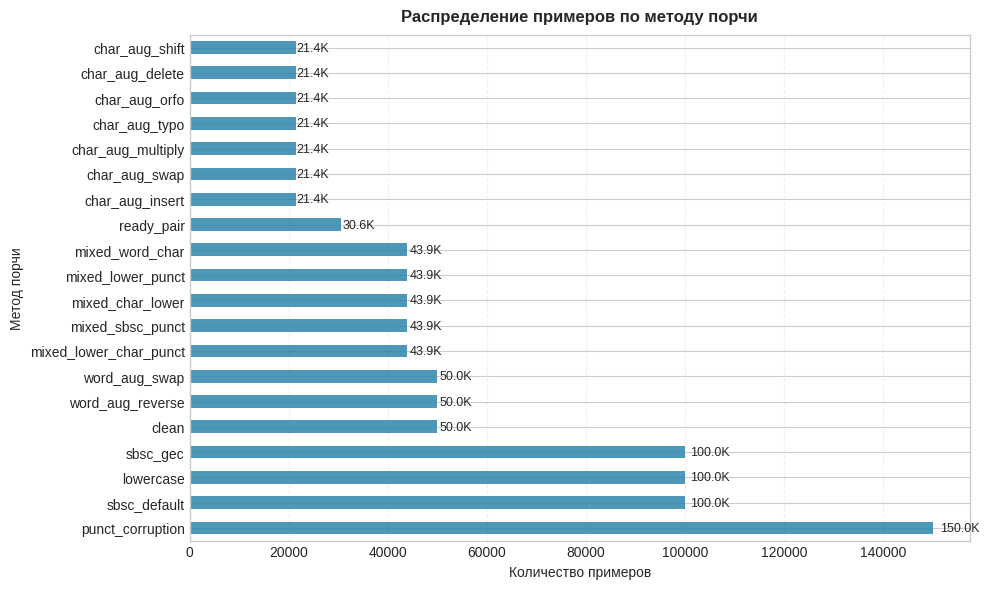

✓ График "distribution_by_method.png" сохранён


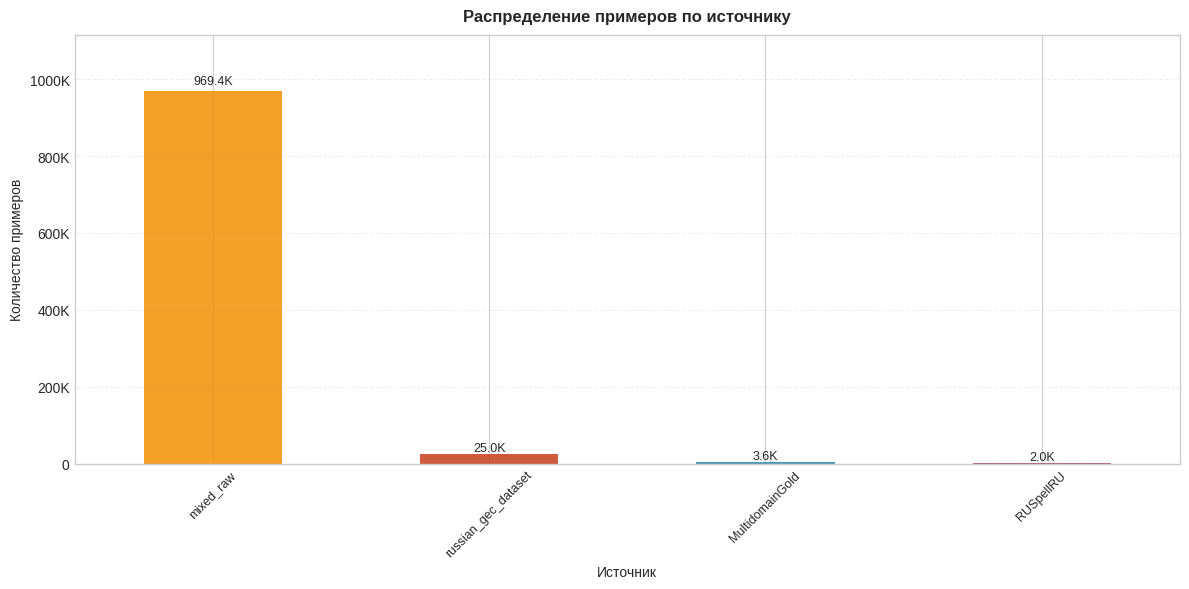

✓ График "distribution_by_source.png" сохранён


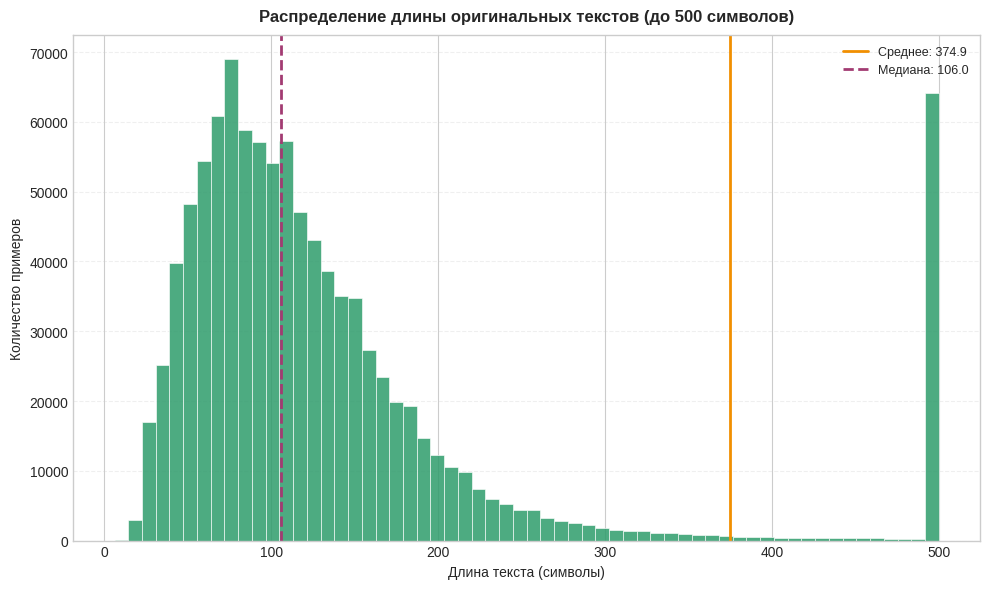

✓ График "text_length_histogram.png" сохранён


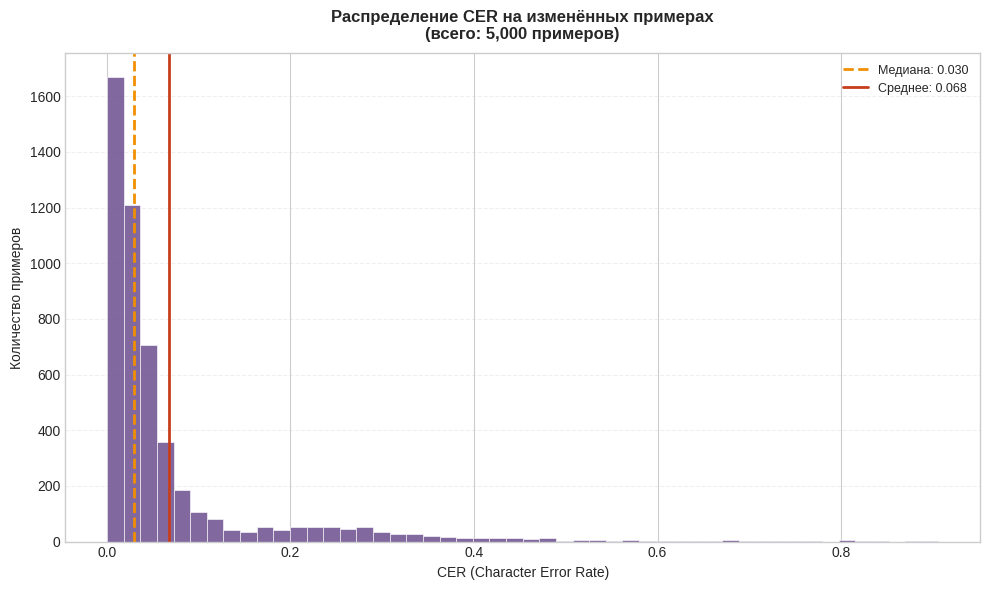

✓ График "cer_histogram.png" сохранён


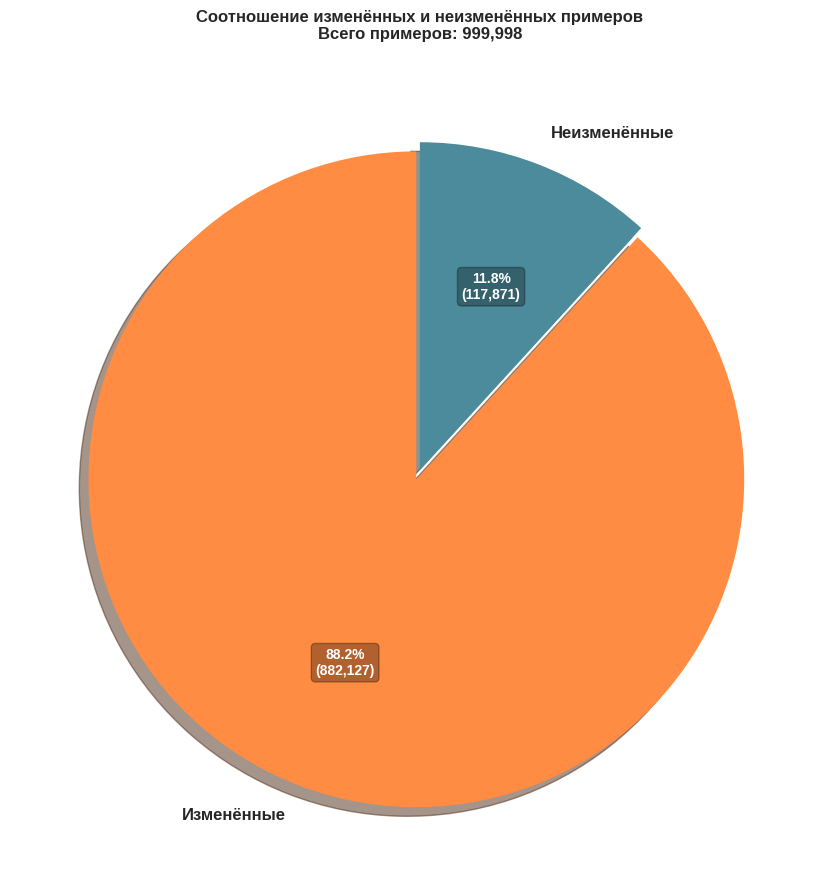

✓ График "is_changed_pie.png" сохранён


In [ ]:
# Визуализация
output_dir = Path("../data/graphics/synth_spell_correction_1m")

# Единые настройки стиля для всех графиков
plt.style.use("seaborn-v0_8-whitegrid")
colors_palette = {
    "primary": "#2E86AB",
    "secondary": "#A23B72",
    "accent1": "#F18F01",
    "accent2": "#C73E1D",
    "green": "#2E9C6B",
    "purple": "#6B4E8E",
    "pie1": "#FF8C42",
    "pie2": "#4B8B9B",
}

# 1. Распределение по методам (barh)
fig1, ax1 = plt.subplots(figsize=(10, 6))
method_counts.plot(kind="barh", ax=ax1, color=colors_palette["primary"], alpha=0.85)
ax1.set_title(
    "Распределение примеров по методу порчи", fontsize=12, fontweight="bold", pad=10
)
ax1.set_xlabel("Количество примеров", fontsize=10)
ax1.set_ylabel("Метод порчи", fontsize=10)
ax1.grid(axis="x", alpha=0.3, linestyle="--")
# Добавляем значения на бары
for i, (bar, value) in enumerate(zip(ax1.patches, method_counts.values)):
    ax1.text(
        bar.get_width() + bar.get_width() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value / 1e3:.1f}K" if value >= 1000 else f"{value:.0f}",
        ha="left",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
plt.savefig(output_dir / "distribution_by_method.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print('✓ График "distribution_by_method.png" сохранён')

# 2. Распределение по источникам (bar, разные цвета)
fig2, ax2 = plt.subplots(figsize=(12, 6))
colors = [
    colors_palette["accent1"],
    colors_palette["accent2"],
    colors_palette["primary"],
    colors_palette["secondary"],
    colors_palette["green"],
][: len(source_counts)]
bars = source_counts.plot(kind="bar", ax=ax2, color=colors, legend=False, alpha=0.85)
ax2.set_title(
    "Распределение примеров по источнику", fontsize=12, fontweight="bold", pad=10
)
ax2.set_ylabel("Количество примеров", fontsize=10)
ax2.set_xlabel("Источник", fontsize=10)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x / 1e3:.0f}K" if x >= 1000 else f"{x:.0f}")
)
ax2.set_ylim(0, source_counts.max() * 1.15)
ax2.tick_params(axis="x", rotation=45, labelsize=9)
ax2.grid(axis="y", alpha=0.3, linestyle="--")
# Добавляем значения на столбцы
for bar, value in zip(ax2.patches, source_counts.values):
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + height * 0.01,
        f"{value / 1e3:.1f}K" if value >= 1000 else f"{value:.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.savefig(output_dir / "distribution_by_source.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print('✓ График "distribution_by_source.png" сохранён')

# 3. Гистограмма длин оригинальных текстов
fig3, ax3 = plt.subplots(figsize=(10, 6))
df["text_len"].clip(upper=500).hist(
    bins=60,
    ax=ax3,
    color=colors_palette["green"],
    edgecolor="white",
    alpha=0.85,
    linewidth=0.5,
)
ax3.set_title(
    "Распределение длины оригинальных текстов (до 500 символов)",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
ax3.set_xlabel("Длина текста (символы)", fontsize=10)
ax3.set_ylabel("Количество примеров", fontsize=10)
ax3.grid(axis="y", alpha=0.3, linestyle="--")
# Добавляем линию среднего и медианы
mean_val = df["text_len"].mean()
median_val = df["text_len"].median()
ax3.axvline(
    mean_val,
    color=colors_palette["accent1"],
    linestyle="-",
    linewidth=2,
    label=f"Среднее: {mean_val:.1f}",
)
ax3.axvline(
    median_val,
    color=colors_palette["secondary"],
    linestyle="--",
    linewidth=2,
    label=f"Медиана: {median_val:.1f}",
)
ax3.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(output_dir / "text_length_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print('✓ График "text_length_histogram.png" сохранён')

# 4. Гистограмма CER
fig4, ax4 = plt.subplots(figsize=(10, 6))
ax4.hist(
    cers,
    bins=50,
    color=colors_palette["purple"],
    edgecolor="white",
    alpha=0.85,
    linewidth=0.5,
)
ax4.set_title(
    f"Распределение CER на изменённых примерах\n(всего: {len(sample_df):,} примеров)",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
ax4.set_xlabel("CER (Character Error Rate)", fontsize=10)
ax4.set_ylabel("Количество примеров", fontsize=10)
ax4.grid(axis="y", alpha=0.3, linestyle="--")
# Добавляем линию медианы
median_cer = np.median(cers)
mean_cer = np.mean(cers)
ax4.axvline(
    median_cer,
    color=colors_palette["accent1"],
    linestyle="--",
    linewidth=2,
    label=f"Медиана: {median_cer:.3f}",
)
ax4.axvline(
    mean_cer,
    color=colors_palette["accent2"],
    linestyle="-",
    linewidth=2,
    label=f"Среднее: {mean_cer:.3f}",
)
ax4.legend(loc="upper right", fontsize=9)
# Добавляем текст с квантилями
plt.tight_layout()
plt.savefig(output_dir / "cer_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print('✓ График "cer_histogram.png" сохранён')

# 5. Pie plot для is_changed (изменённые vs неизменённые примеры)
fig5, ax5 = plt.subplots(figsize=(9, 9))
changed_counts = df["is_changed"].value_counts()
labels = (
    ["Изменённые", "Неизменённые"]
    if True in changed_counts.index
    else changed_counts.index.astype(str)
)
values = changed_counts.values
total = sum(values)


def autopct_format(pct):
    absolute = int(round(pct / 100.0 * total))
    return f"{pct:.1f}%\n({absolute:,})"


wedges, texts, autotexts = ax5.pie(
    values,
    labels=labels,
    autopct=autopct_format,
    colors=[colors_palette["pie1"], colors_palette["pie2"]],
    startangle=90,
    explode=(0.03, 0),
    shadow=True,
    textprops={"fontsize": 11},
)

# Стилизация текста
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight("bold")
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color("white")
    autotext.set_fontweight("bold")
    autotext.set_bbox(dict(boxstyle="round", facecolor="black", alpha=0.3))

ax5.set_title(
    f"Соотношение изменённых и неизменённых примеров\nВсего примеров: {total:,}",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.savefig(output_dir / "is_changed_pie.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print('✓ График "is_changed_pie.png" сохранён')

In [ ]:
# Примеры из каждого метода
print("\nПРИМЕРЫ (по 2 на каждый метод):")
print("=" * 80)
for method in df["method"].unique():
    subset = df[df["method"] == method].sample(
        min(2, (df["method"] == method).sum()), random_state=SEED
    )
    print(f"\n[{method}]")
    for _, row in subset.iterrows():
        orig = row["text"][:120].replace("\n", " ")
        corr = row["text_corrupt"][:120].replace("\n", " ")
        print(f"  ОРИГИНАЛ:    {orig}")
        print(f"  ИСПОРЧЕННЫЙ: {corr}")
        print()


ПРИМЕРЫ (по 2 на каждый метод):

[mixed_lower_char_punct]
  ОРИГИНАЛ:    В местном отделении Управления по борьбе с незаконным оборотов наркотиков заявили, что весь экипаж, а также трое их сооб
  ИСПОРЧЕННЫЙ: в местном отделенииц управления по борьбе с незаконным оборотов наркотиков заявили что весь экипаж, а такжед трое их соо

  ОРИГИНАЛ:    Многие комментаторы попробовали вручную дорисовать щенку тело на фотографии.
  ИСПОРЧЕННЫЙ: многие комментАторы попробовали; вручную дорисовать Щенку тЕло на фотографии


[clean]
  ОРИГИНАЛ:    В феврале журнал People составил список культовых эротических сцен в истории мирового кинематографа.
  ИСПОРЧЕННЫЙ: В феврале журнал People составил список культовых эротических сцен в истории мирового кинематографа.

  ОРИГИНАЛ:    В то же время, по информации издания, концерт пришлось отменить не из-за протестов, а из-за того, что билетов было прода
  ИСПОРЧЕННЫЙ: В то же время, по информации издания, концерт пришлось отменить не из-за протестов, а из-з

In [26]:
# Итоговая сводка
print("\n" + "=" * 60)
print("ИТОГОВАЯ СВОДКА")
print("=" * 60)
print()
print(
    df.groupby("method")
    .agg(
        count=("text", "count"),
        changed_pct=("is_changed", lambda x: f"{x.mean() * 100:.1f}%"),
        avg_orig_len=("text_len", lambda x: f"{x.mean():.0f}"),
    )
    .to_string()
)


ИТОГОВАЯ СВОДКА

                         count changed_pct avg_orig_len
method                                                 
char_aug_delete          21428      100.0%          383
char_aug_insert          21432      100.0%          382
char_aug_multiply        21428        1.2%          377
char_aug_orfo            21428       99.8%          390
char_aug_shift           21428       99.7%          383
char_aug_swap            21428      100.0%          384
char_aug_typo            21428       99.3%          388
clean                    50000        1.2%          380
lowercase               100000       99.6%          386
mixed_char_lower         43886       99.9%          389
mixed_lower_char_punct   43887      100.0%          375
mixed_lower_punct        43886       99.9%          383
mixed_sbsc_punct         43886       96.8%          380
mixed_word_char          43886       99.7%          390
punct_corruption        150000       89.4%          388
ready_pair               30567